# Урок 08. Ключевые распределения

> **Зачем это нужно:** реальные данные следуют распределениям. Зная их свойства, вы предсказываете поведение моделей, ставите разумные априорные, понимаете, когда применима ЦПТ.

---

В машинном обучении выбор распределения определяет архитектуру модели, выбор функции потерь (Loss Function) и методы регуляризации.

---

## I. Дискретные распределения (Счетные исходы)

### 1. Распределение Бернулли: $X \sim \text{Bernoulli}(p)$
Описывает один эксперимент с двумя исходами: «успех» ($X=1$) с вероятностью $p$ или «неудача» ($X=0$) с вероятностью $1-p$.

* **Формула вероятности:**
$$P(X = k) = p^k (1-p)^{1-k}, \quad \text{где } k \in \{0, 1\}$$
* **Математическое ожидание:** $E[X] = p$
* **Дисперсия:** $Var(X) = p(1-p)$
* **Теория и ML-интуиция:** Базовый профиль для **бинарной классификации** (клик/не клик, фрод/не фрод). Лежит в основе функции потерь **Binary Cross-Entropy (BCE)** в логистической регрессии и нейросетях.

### 2. Биномиальное распределение: $X \sim \text{Bin}(n, p)$
Описывает суммарное количество «успехов» $k$ в серии из $n$ независимых испытаний Бернулли.

* **Формула вероятности:**
$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad \text{где } k \in \{0, 1, \dots, n\}$$
*Где $\binom{n}{k} = \frac{n!}{k!(n-k)!}$ — число сочетаний.*
* **Математическое ожидание:** $E[X] = np$
* **Дисперсия:** $Var(X) = np(1-p)$
* **Теория и ML-интуиция:** Используется для моделирования конверсий групп пользователей, расчета доверительных интервалов в **A/B-тестировании** и при оценке стабильности бинарных признаков.

### 3. Распределение Пуассона: $X \sim \text{Poisson}(\lambda)$
Описывает количество случайных событий, происходящих за фиксированный интервал времени/пространства с постоянной средней интенсивностью $\lambda$.

* **Формула вероятности:**
$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad \text{где } k \in \{0, 1, 2, \dots\}, \, \lambda > 0$$
* **Математическое ожидание:** $E[X] = \lambda$
* **Дисперсия:** $Var(X) = \lambda$ *(уникальное свойство: матожидание равно дисперсии)*
* **Теория и ML-интуиция:** Моделирует **потоки событий** (кол-во заходов на сайт в минуту, число запросов к API). Применяется в Пуассоновской регрессии (Poisson Regression) для предсказания счетчиков (count data).
* **Применение:** число посещений сайта в час, число дефектов в товаре.

---

## II. Непрерывные распределения (Дробные значения)

### 4. Нормальное (Гауссовское) распределение: $X \sim \mathcal{N}(\mu, \sigma^2)$
Симметричное распределение, имеющее форму колокола. Большинство значений группируется вокруг центра $\mu$.

* **Функция плотности вероятности (PDF):**
$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left( -\frac{(x - \mu)^2}{2\sigma^2} \right), \quad \text{где } x \in (-\infty, +\infty)$$
* **Математическое ожидание:** $E[X] = \mu$
* **Дисперсия:** $Var(X) = \sigma^2$
* **Теория и ML-интуиция:** Самое важное распределение. К нему сводятся случайные ошибки моделей. Если таргет распределен нормально, математически обосновано применение функции потерь **MSE (Mean Squared Error)** и метода наименьших квадратов.
* **Правило 68-95-99.7:** в пределах `σ` лежит 68% массы, `2σ` — 95%, `3σ` — 99.7%. Это вы будете использовать в A/B-тестах постоянно.
* **Где в ML:** инициализация весов (Xavier, He), Gaussian noise, гауссовские априорные.

### 5. Экспоненциальное (Показательное) распределение: $X \sim \text{Exp}(\lambda)$
Описывает интервалы времени или расстояния между последовательными событиями в пуассоновском потоке.

* **Функция плотности вероятности (PDF):**
$$f(x) = \begin{cases} \lambda e^{-\lambda x}, & x \ge 0 \\ 0, & x < 0 \end{cases}, \quad \text{где } \lambda > 0 \text{ — интенсивность}$$
* **Математическое ожидание:** $E[X] = \frac{1}{\lambda}$
* **Дисперсия:** $Var(X) = \frac{1}{\lambda^2}$
* **Теория и ML-интуиция:** Обладает свойством «отсутствия памяти» ($P(X > s + t \mid X > s) = P(X > t)$). То, что вы прождали 10 минут, не делает следующее событие ближе. Применяется в **Survival Analysis (анализ выживаемости)** для предсказания времени до оттока клиента (Churn) или поломки оборудования.

### 6. Многомерное нормальное распределение: $\mathbf{X} \sim \mathcal{N}(\boldsymbol{\mu}, \mathbf{\Sigma})$
Обобщение одномерного распределения Гаусса на случай $d$-мерного вектора случайных величин, учитывающее их взаимосвязи.

* **Функция плотности вероятности (PDF):**
$$f(\mathbf{x}) = \frac{1}{(2\pi)^{d/2} |\mathbf{\Sigma}|^{1/2}} \exp\left( -\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}) \right)$$
*Где $\mathbf{x}, \boldsymbol{\mu}$ — векторы длины $d$, $\mathbf{\Sigma}$ — ковариационная матрица размера $d \times d$, а $|\mathbf{\Sigma}|$ — её определитель.*
* **Математическое ожидание (вектор):** $E[\mathbf{X}] = \boldsymbol{\mu}$
* **Дисперсия (ковариационная матрица):** $Var(\mathbf{X}) = \mathbf{\Sigma}$
* **Теория и ML-интуиция:** Фундамент для линейного дискриминантного анализа (LDA), Гауссовских процессов (Gaussian Processes) и алгоритмов кластеризации (Гауссовские смеси — GMM через EM-алгоритм).

---

## III. Априорные распределения (Байесовский ML)

### 7. Бета-распределение: $X \sim \text{Beta}(\alpha, \beta)$
Непрерывное распределение, заданное на интервале $[0, 1]$. Описывает неопределенность относительно самой *вероятности* успеха.

* **Функция плотности вероятности (PDF):**
$$f(x) = \frac{1}{B(\alpha, \beta)} x^{\alpha - 1} (1 - x)^{\beta - 1}, \quad \text{где } x \in, \, \alpha > 0, \beta > 0$$
*Где $B(\alpha, \beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha + \beta)}$ — Бета-функция, нормирующая площадь до 1.*
* **Математическое ожидание:** $E[X] = \frac{\alpha}{\alpha + \beta}$
* **Дисперсия:** $Var(X) = \frac{\alpha\beta}{(\alpha + \beta)^2(\alpha + \beta + 1)}$
* **Теория и ML-интуиция:** В байесовском подходе это **сопряженное априорное распределение** для распределения Бернулли. Если у нас есть монетка, параметры $\alpha$ и $\beta$ моделируют наши изначальные знания (мыслимые орлы и решки). При обновлении данных по формуле Байеса нам нужно просто прибавить реальные успехи к $\alpha$, а неудачи к $\beta$.

### 8. Распределение Дирихле: $\mathbf{X} \sim \text{Dirichlet}(\boldsymbol{\alpha})$
Многомерное обобщение Бета-распределения. Описывает распределение вероятностей над векторами, компоненты которых в сумме дают 1 (вероятностные симплексы).

* **Функция плотности вероятности (PDF):**
$$f(x_1, \dots, x_K) = \frac{1}{\mathrm{B}(\boldsymbol{\alpha})} \prod_{i=1}^{K} x_i^{\alpha_i - 1}, \quad \text{где } \sum_{i=1}^K x_i = 1, \, x_i \ge 0, \, \alpha_i > 0$$
* **Математическое ожидание для компоненты $X_i$:** $E[X_i] = \frac{\alpha_i}{\sum_{j=1}^K \alpha_j}$
* **Дисперсия для компоненты $X_i$:** $Var(X_i) = \frac{\alpha_i (\alpha_0 - \alpha_i)}{\alpha_0^2 (\alpha_0 + 1)}, \quad \text{где } \alpha_0 = \sum_{j=1}^K \alpha_j$
* **Теория и ML-интуиция:** Сопряженное априорное распределение для Мультиномиального распределения (много кубиков или классов). Главный инструмент в **тематическом моделировании текстов (LDA — Latent Dirichlet Allocation)**, где документ представляется как смесь тем, а тема — как смесь слов.

---

## IV. Центральная предельная теорема (ЦПТ / CLT)

**Центральная предельная теорема** объясняет, почему нормальное распределение доминирует в природе и машинном обучении.

### Строгая формулировка
Пусть $X_1, X_2, \dots, X_n$ — последовательность независимых и одинаково распределенных (i.i.d.) случайных величин с любым (хоть абсолютно диким и нелинейным) законом распределения, но имеющих конечное матожидание $\mu$ и конечную дисперсию $\sigma^2$.

Тогда с ростом $n$ распределение их суммы $S_n = \sum_{i=1}^n X_i$ и их выборочного среднего $\bar{X}_n = \frac{1}{n} S_n$ стремится к **нормальному распределению**, независимо от того, каков был исходный закон распределения элементов:

$$\bar{X}_n \xrightarrow{d} \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right) \quad \text{при } n \to \infty$$

### Почему это критически важно для ML?
1. **Шум везде нормален:** Ошибка предсказания модели в реальности складывается из сотен мелких независимых факторов (погрешность датчиков, округление, погода, настроение пользователя). Даже если каждый фактор распределен странно, их суммарный эффект (шум) по ЦПТ будет нормальным.
2. **Линейные модели:** В линейной регрессии веса настраиваются на основе сумм признаков объектов выборки. ЦПТ гарантирует, что при больших объемах данных параметры модели будут распределены асимптотически нормально, что позволяет строить для них строгие доверительные интервалы (p-values).


---

In [1]:
import numpy as np
import scipy.stats as stats
import seaborn as sns
from matplotlib import pyplot as plt

rng = np.random.default_rng(seed=42)
size = 1000


In [2]:
# Распределение Бернулли
p_bern = 0.3
samples_bern = rng.binomial(n=1, p=p_bern, size=size)
print(f"1. Bernoulli (p={p_bern})")
print(f"   Теория: E[X] = {p_bern:.4f}, Var(X) = {p_bern*(1-p_bern):.4f}")
print(f"   Выборка: среднее = {samples_bern.mean():.4f}, дисперсия = {samples_bern.var():.4f}\n")

1. Bernoulli (p=0.3)
   Теория: E[X] = 0.3000, Var(X) = 0.2100
   Выборка: среднее = 0.3040, дисперсия = 0.2116



In [3]:
# Биномиальное распределение
n_bin, p_bin = 10, 0.5
samples_bin = rng.binomial(n=n_bin, p=p_bin, size=size)
print(f"2. Binomial (n={n_bin}, p={p_bin})")
print(f"   Теория: E[X] = {n_bin*p_bin:.4f}, Var(X) = {n_bin*p_bin*(1-p_bin):.4f}")
print(f"   Выборка: среднее = {samples_bin.mean():.4f}, дисперсия = {samples_bin.var():.4f}\n")

2. Binomial (n=10, p=0.5)
   Теория: E[X] = 5.0000, Var(X) = 2.5000
   Выборка: среднее = 5.0790, дисперсия = 2.4828



In [4]:
lam_poisson = 4.0
samples_poisson = rng.poisson(lam=lam_poisson, size=size)
print(f"3. Poisson (lambda={lam_poisson})")
print(f"   Теория: E[X] = {lam_poisson:.4f}, Var(X) = {lam_poisson:.4f}")
print(f"   Выборка: среднее = {samples_poisson.mean():.4f}, дисперсия = {samples_poisson.var():.4f}\n")

3. Poisson (lambda=4.0)
   Теория: E[X] = 4.0000, Var(X) = 4.0000
   Выборка: среднее = 3.9170, дисперсия = 3.9401



In [5]:
mu, sigma = 0.0, 1.0
samples_normal = rng.normal(loc=mu, scale=sigma, size=size)
print(f"4. Normal (mu={mu}, sigma={sigma})")
print(f"   Теория: E[X] = {mu:.4f}, Var(X) = {sigma**2:.4f}")
print(f"   Выборка: среднее = {samples_normal.mean():.4f}, дисперсия = {samples_normal.var():.4f}\n")

4. Normal (mu=0.0, sigma=1.0)
   Теория: E[X] = 0.0000, Var(X) = 1.0000
   Выборка: среднее = -0.0257, дисперсия = 0.9648



In [6]:
lam_exp = 2.0
samples_exp = rng.exponential(scale=1/lam_exp, size=size)
print(f"5. Exponential (lambda={lam_exp})")
print(f"   Теория: E[X] = {1/lam_exp:.4f}, Var(X) = {1/(lam_exp**2):.4f}")
print(f"   Выборка: среднее = {samples_exp.mean():.4f}, дисперсия = {samples_exp.var():.4f}\n")

5. Exponential (lambda=2.0)
   Теория: E[X] = 0.5000, Var(X) = 0.2500
   Выборка: среднее = 0.4916, дисперсия = 0.2437



In [7]:
means_2d = np.array([1.0, 2.0])
cov_2d = np.array([[1.0, 0.5],
                   [0.5, 2.0]])
samples_multivariate = rng.multivariate_normal(mean=means_2d, cov=cov_2d, size=size)
print(f"6. Multivariate Normal (2D)")
print(f"   Теория: матожидание = {means_2d}")
print(f"   Теория: ковариация =\n{cov_2d}")
print(f"   Выборка: среднее = {samples_multivariate.mean(axis=0)}")
print(f"   Выборка: ковариация =\n{np.cov(samples_multivariate, rowvar=False)}\n")

6. Multivariate Normal (2D)
   Теория: матожидание = [1. 2.]
   Теория: ковариация =
[[1.  0.5]
 [0.5 2. ]]
   Выборка: среднее = [0.94726903 1.98980183]
   Выборка: ковариация =
[[1.03217998 0.58447642]
 [0.58447642 2.20998408]]



In [8]:
alpha, beta = 2.0, 5.0
samples_beta = rng.beta(a=alpha, b=beta, size=size)

# Используем scipy для автоматического расчета честной теории сложных функций
theory_beta_mean, theory_beta_var = stats.beta.stats(a=alpha, b=beta, moments='mv')

print(f"7. Beta (alpha={alpha}, beta={beta})")
print(f"   Теория: E[X] = {theory_beta_mean:.4f}, Var(X) = {theory_beta_var:.4f}")
print(f"   Выборка: среднее = {samples_beta.mean():.4f}, дисперсия = {samples_beta.var():.4f}\n")


7. Beta (alpha=2.0, beta=5.0)
   Теория: E[X] = 0.2857, Var(X) = 0.0255
   Выборка: среднее = 0.2792, дисперсия = 0.0256



In [9]:
alpha_vec = np.array([2, 3, 5])
samples_dirichlet = rng.dirichlet(alpha=alpha_vec, size=size)
print(samples_dirichlet)

theory_dir_mean = alpha_vec / alpha_vec.sum()

print(f"8. Dirichlet (alphas={alpha_vec})")
print(f"   Теория: вектор матожиданий = {theory_dir_mean}")
print(f"   Выборка: вектор средних    = {samples_dirichlet.mean(axis=0)}")

[[0.33074655 0.09871383 0.57053961]
 [0.08132863 0.52229487 0.39637649]
 [0.18343512 0.35842751 0.45813737]
 ...
 [0.2907782  0.57855877 0.13066302]
 [0.05402583 0.3433252  0.60264896]
 [0.10075747 0.52490701 0.37433552]]
8. Dirichlet (alphas=[2 3 5])
   Теория: вектор матожиданий = [0.2 0.3 0.5]
   Выборка: вектор средних    = [0.20472712 0.29247503 0.50279786]


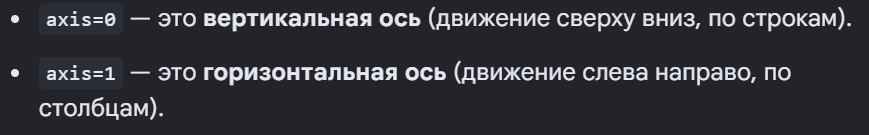
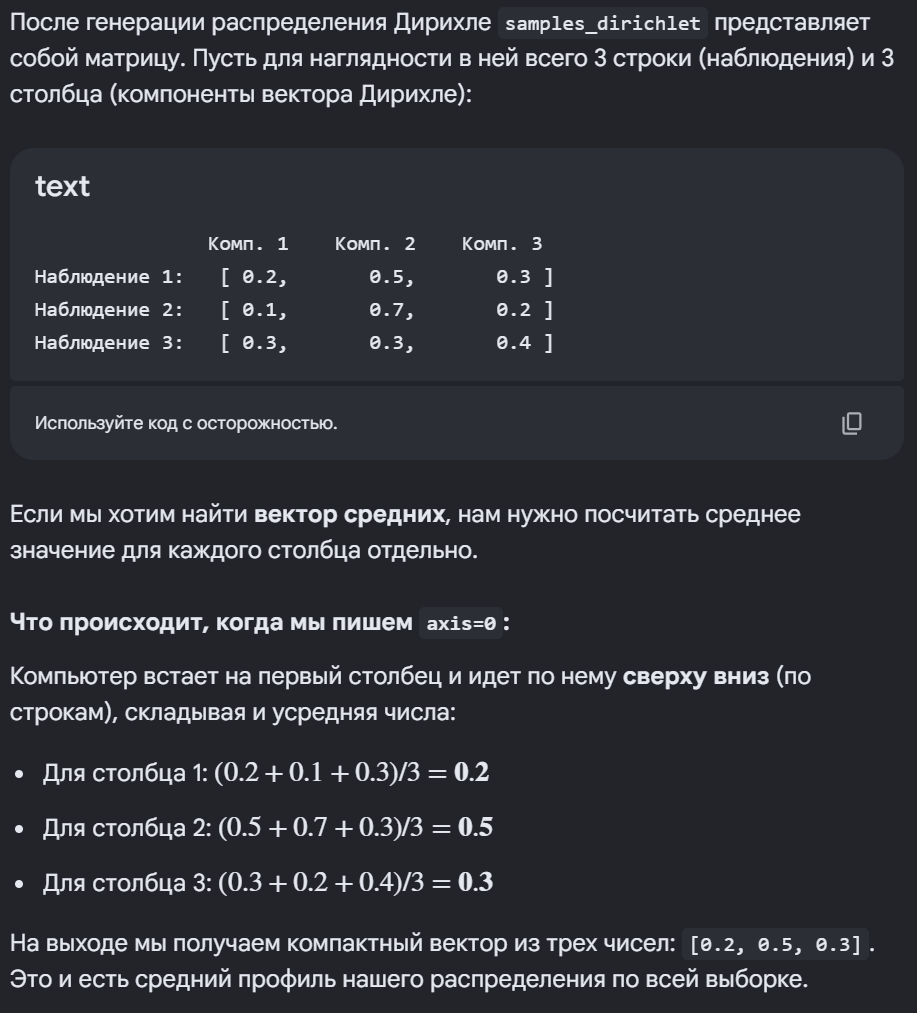

---
---
# Подробный разбор 8 ключевых распределений в Machine Learning

---

## 1. Распределение Бернулли (Bernoulli Distribution)

### Жизненная аналогия
Один бросок монетки. У вас есть ровно два исхода: либо событие произошло (1), либо нет (0). 

### Математический смысл параметров
* **$p$** — вероятность успеха (число от 0 до 1). Соответственно, вероятность неудачи автоматически равна $1-p$.
* Распределение отвечает на вопрос: *«Каков шанс, что в ОДНОМ случайном испытании мы получим успех?»*

### Применение в Machine Learning
* **Бинарная классификация:** Это идеальная модель для предсказания двух классов. Например: $1$ — пользователь кликнет по рекламе, $0$ — не кликнет.
* **Функция потерь BCE (Binary Cross-Entropy):** Когда логистическая регрессия или нейросеть обучается разделять два класса, под капотом она ищет такой параметр $p$ для распределения Бернулли, который максимизирует вероятность правильного ответа.

---

## 2. Биномиальное распределение (Binomial Distribution)

### Жизненная аналогия
Вы подбрасываете монетку не 1 раз, а серию из 10 раз. Биномиальное распределение показывает, с какой вероятностью у вас выпадет ровно 3 орла, ровно 5 орлов или все 10.

### Математический смысл параметров
* **$n$** — количество независимых испытаний в серии.
* **$p$** — вероятность успеха в каждом отдельном испытании.
* Распределение отвечает на вопрос: *«Какова вероятность получить ровно $k$ успехов, если мы сделаем $n$ попыток?»*

### Применение в Machine Learning
* **A/B-тестирование:** Если базовый уровень конверсии сайта равен $p=2\%$, и мы запускаем на сайт $n=1000$ пользователей, биномиальное распределение помогает понять, является ли всплеск до 40 покупок случайным шумом или наша новая кнопка действительно работает.
* **Оценка метрик:** Помогает строить доверительные интервалы для точности (Accuracy) моделей на тестовой выборке.

---

## 3. Распределение Пуассона (Poisson Distribution)

### Жизненная аналогия
Очередь в кассу или поток машин на перекрестке. Вы знаете, что в среднем на сайт заходит 5 человек в минуту. Но в какую-то конкретную минуту может зайти 2 человека, а в другую — 12. 

### Математический смысл параметров
* **$\lambda$ (лямбда)** — среднее количество событий, происходящих за фиксированный интервал времени или пространства.
* Распределение отвечает на вопрос: *«Какова вероятность, что за следующий час произойдет ровно $k$ редких событий, если в среднем их происходит $\lambda$?»*

### Применение в Machine Learning
* **Прогноз счетчиков (Count Data):** Обычная регрессия плохо предсказывает целые неотрицательные числа (вызовы в колл-центр, количество заказов такси в час, число писем в ящике). Для этого используют **Пуассоновскую регрессию**.
* Уникальное свойство распределения ($E[X] = Var(X) = \lambda$) активно используется для проверки того, является ли поток данных истинно случайным или в нем есть скрытые зависимости.

---

## 4. Нормальное (Гауссово) распределение (Normal Distribution)

### Жизненная аналогия
Рост людей в городе. Большинство мужчин имеют средний рост около 175 см. Людей с ростом 173 или 177 см тоже очень много. Но встретить человека ростом 150 см или 210 см — огромная редкость. График выглядит как идеальный симметричный колокол.

### Математический смысл параметров
* **$\mu$ (му)** — математическое ожидание. Это вершина колокола, центр, вокруг которого все крутится.
* **$\sigma$ (сигма)** — среднеквадратическое отклонение. Оно отвечает за ширину колокола. Маленькая сигма — колокол узкий и острый (все данные прижаты к центру). Большая сигма — колокол широкий и плоский (данные сильно размыты).

### Применение в Machine Learning
* **Функция потерь MSE:** Когда мы обучаем линейную регрессию минимизировать среднеквадратичную ошибку (MSE), мы на самом деле предполагаем, что ошибки нашей модели распределены по закону Гаусса вокруг реального значения.
* **Предобработка данных:** Алгоритмы (особенно нейросети и линейные модели) работают намного лучше, если все входные признаки распределены нормально. Поэтому их насильно приводят к такому виду с помощью `StandardScaler` ($\mu=0, \sigma=1$).

---

## 5. Экспоненциальное распределение (Exponential Distribution)

### Жизненная аналогия
Время ожидания автобуса на остановке или время работы лампочки до перегорания. Плотность этого распределения максимальна в нуле и стремительно падает вниз. Это значит, что короткие интервалы времени между событиями случаются постоянно, а огромные периоды затишья — очень редко.

### Математический смысл параметров
* **$\lambda$ (лямбда)** — интенсивность событий. Чем выше интенсивность, тем быстрее график падает к нулю (события происходят чаще, значит, ждать приходится меньше).
* Матожидание (среднее время ожидания) равно обратному значению: $1 / \lambda$.

### Применение в Machine Learning
* **Анализ выживаемости (Survival Analysis):** Используется в ML-моделях, которые предсказывают время до наступления критического события. Например: через сколько дней клиент отменит подписку (Churn), или через сколько часов непрерывной работы сломается сервер на заводе.

---

## 6. Многомерное нормальное распределение (Multivariate Normal)

### Жизненная аналогия
Если обычное распределение Гаусса — это 2D-колокол на плоскости (только Рост), то многомерное — это 3D-холм или целая горная гряда (Рост и Вес одновременно). Оно учитывает, что у людей с большим ростом обычно и вес больше, то есть признаки взаимосвязаны.

### Математический смысл параметров
* **$\boldsymbol{\mu}$** — не просто число, а *вектор средних значений* для каждого признака.
* **$\mathbf{\Sigma}$ (матрица ковариации)** — таблица, которая показывает разброс каждого признака в отдельности (на главной диагонали) и силу линейной связи между ними (вне диагонали).

### Применение в Machine Learning
* **Алгоритм детекции аномалий (GMM):** Модель строит такое многомерное облако вокруг нормальных данных. Если новая точка (например, транзакция по карте) улетает далеко подножие этого «холма», система маркирует её как подозрительную.
* **Снижение размерности (PCA):** Метод главных компонент напрямую работает с матрицей ковариации многомерного нормального распределения, чтобы сжать 100 признаков в 2 или 3 главных без потери важной информации.

---

## 7. Бета-распределение (Beta Distribution)

### Жизненная аналогия
Это «распределение вероятностей над вероятностями». Представьте, что вы нашли на улице незнакомую монетку. Вы не знаете, честная она или фальшивая. Вы подбросили её 5 раз, и она 4 раза упала орлом. Бета-распределение позволяет математически описать вашу текущую уверенность в том, какова *истинная* вероятность выпадения орла у этой монетки.

### Математический смысл параметров
* **$\alpha$ (альфа)** — условное количество увиденных «успехов» (орлов) + 1.
* **$\beta$ (бета)** — условное количество увиденных «неудач» (решек) + 1.
* Изменяя эти параметры, график Бета-распределения (который зажат строго между 0 и 1) может принимать любые формы: быть симметричным колоколом, сползать к краям или превращаться в прямую линию.

### Применение в Machine Learning
* **Байесовский ML (Априорные знания):** Используется как идеальный инструмент для обновления знаний модели. Мы закладываем стартовые $\alpha$ и $\beta$ (наше априорное предположение), а затем, когда модель видит новые данные, мы просто прибавляем реальные успехи к $\alpha$, а неудачи к $\beta$.
* Активно применяется в рекомендательных системах для решения задачи «Исследование против Эксплуатации» (Exploration vs Exploitation), например, в алгоритме *Thompson Sampling*.

---

## 8. Распределение Дирихле (Dirichlet Distribution)

### Жизненная аналогия
Это старший многомерный брат Бета-распределения. Если Бета-распределение делит мир на два исхода (орел/решка), то Дирихле работает, когда исходов много (как у игрального кубика с 6 гранями). Оно описывает, с какой вероятностью кубик смещен в сторону тех или иных граней.

### Математический смысл параметров
* **$\boldsymbol{\alpha}$** — вектор параметров (счетчиков) для каждого возможного исхода.
* Результатом генерации из распределения Дирихле всегда является **вектор вероятностей**, компоненты которого в сумме строго дают единицу (например, `[0.2, 0.5, 0.3]`).

### Применение в Machine Learning
* **Тематическое моделирование текстов (LDA):** Главный алгоритм, который берет миллионы статей и раскладывает их по темам (например, 20% Политика, 50% Спорт, 30% Наука). Распределение Дирихле используется там под капотом как априорный фильтр, который управляет тем, насколько темы в документах могут смешиваться между собой.


---
---
## 8. Практические задания

1. **Графики 5 распределений.** Постройте PDF/PMF для Бернулли, Биномиального, Нормального, Пуассона, Экспоненциального с несколькими наборами параметров.


В теории вероятностей и машинном обучении способы описания случайных величин зависят от их природы. Функции **PMF** и **PDF** решают одну задачу — показывают, как распределена вероятность, — но делают это для разных типов данных.

---

## 1. PMF (Probability Mass Function) — Функция массы вероятности

Применяется **только для дискретных** случайных величин (Бернулли, Биномиальное, Пуассон), значения которых можно четко пересчитать ($0, 1, 2, 3 \dots$).

* **Суть:** PMF возвращает **точную вероятность** того, что случайная величина $X$ примет конкретное дискретное значение $k$.
* **Формула:** 
$$f(k) = P(X = k)$$
* **Свойство нормировки:** Если просуммировать значения PMF для абсолютно всех возможных исходов, мы получим строго единицу:
$$\sum_{k} P(X = k) = 1$$
* **Визуализация:** На графиках PMF никогда не показывают сплошной линией. Её рисуют в виде изолированных точек, «палочек» (`plt.stem`) или столбиков (`plt.bar`). Высота каждого столбика — это реальная вероятность исхода.

---

## 2. PDF (Probability Density Function) — Функция плотности вероятности

Применяется **только для непрерывных** случайных величин (Нормальное, Экспоненциальное, Бета), значения которых измеряются на непрерывной шкале (например, вес, время, стоимость).

* **Суть:** PDF возвращает **плотность вероятности** вокруг точки $x$, а не саму вероятность.
* **Главный парадокс:** Вероятность того, что непрерывная случайная величина примет *абсолютно точное* значение до бесконечного знака после запятой, равна нулю: $P(X = x_0) = 0$. 
* **Как найти вероятность:** Вероятность имеет смысл только для *интервала* (например, шанс, что модель предскажет цену квартиры в диапазоне от 5.0 до 5.5 млн). Геометрически эта вероятность равна **площади под кривой PDF** на заданном отрезке (интегралу):
$$P(a \le X \le b) = \int_{a}^{b} f(x) \, dx$$
* **Свойство нормировки:** Площадь под *всем* графиком PDF от $-\infty$ до $+\infty$ всегда равна единице:
$$\int_{-\infty}^{+\infty} f(x) \, dx = 1$$
* **Визуализация:** PDF всегда рисуется в виде **плавной сплошной линии** (`plt.plot`). Высота графика в конкретной точке может быть больше 1 (так как это плотность), но общая площадь под кривой строго ограничена единицей.

---

## Краткая шпаргалка для работы в Python (SciPy)

| Тип величины | Функция описания | Метод в `scipy.stats` | Тип графика |
| :--- | :--- | :--- | :--- |
| **Дискретная** | **PMF** (Масса) | `.pmf(k, ...)` | Дискретные столбики (`plt.stem` / `plt.bar`) |
| **Непрерывная** | **PDF** (Плотность) | `.pdf(x, ...)` | Гладкая линия (`plt.plot`) |


<>:58: SyntaxWarning: invalid escape sequence '\l'
<>:78: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\s'
<>:101: SyntaxWarning: invalid escape sequence '\l'
<>:58: SyntaxWarning: invalid escape sequence '\l'
<>:78: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\s'
<>:101: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2650/3489059285.py:58: SyntaxWarning: invalid escape sequence '\l'
  ax.vlines(k_poisson, 0, pmf_poisson, colors=color, lw=2, alpha=0.6, label=f"$\lambda$ = {lam}")
/tmp/ipykernel_2650/3489059285.py:78: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x_norm, pdf_norm, color=color, lw=2, label=f"$\mu$={mu}, $\sigma$={sigma}")
/tmp/ipykernel_2650/3489059285.py:78: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(x_norm, pdf_norm, color=color, lw=2, label=f"$\mu$={mu}, $\sigma$={sigma}")
/tmp/ipykernel_2650/3489059285.py:101: SyntaxWarning: invalid escape seque

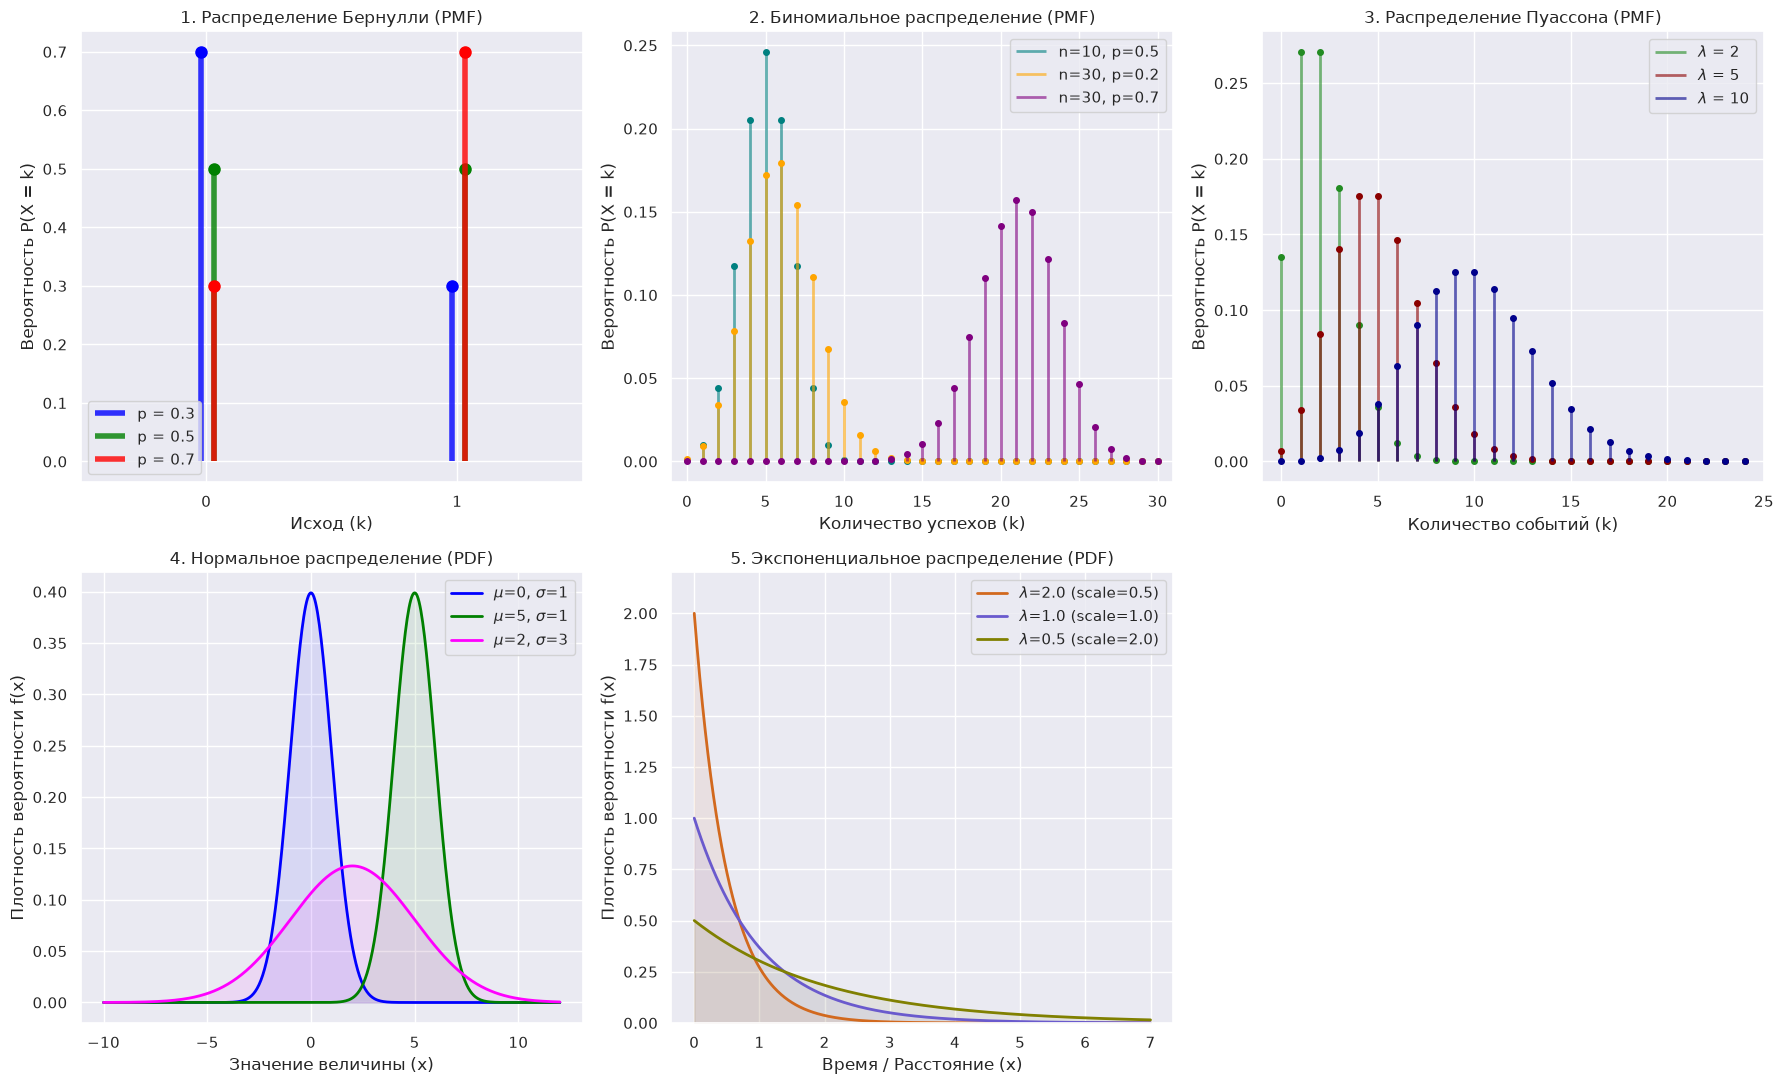

In [10]:
# Настраиваем тему отображения
sns.set_theme(style="darkgrid")

# Создаем сетку 2x3 для графиков (одно знаковое место оставим пустым или объединим)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten() # сглаживаем в одномерный массив для удобной итерации


# 1. РАСПРЕДЕЛЕНИЕ БЕРНУЛЛИ (Дискретное -> PMF)
ax = axes[0]
k_bern = np.array([0, 1]) # возможные исходы
for p, color in zip([0.3, 0.5, 0.7], ["blue", "green", "red"]):
    # Переменная pmf_bern сохраняет массив из двух чисел — вероятности для 0 и для 1
    pmf_bern = stats.bernoulli.pmf(k_bern, p)
    # Смещаем столбики чуть вбок, чтобы они не перекрывали друг друга
    offset = -0.02 if p == 0.3 else 0.03
    ax.vlines(x=k_bern + offset, ymin=0, ymax=pmf_bern, colors=color, lw=4, alpha=0.8, label=f"p = {p}")
    ax.plot(k_bern + offset, pmf_bern, 'o', color=color, ms=8)

ax.set_title("1. Распределение Бернулли (PMF)")
ax.set_xlabel("Исход (k)")
ax.set_ylabel("Вероятность P(X = k)")
ax.set_xticks([0, 1])
ax.set_xlim(-0.5, 1.5)
ax.legend()


# 2. БИНОМИАЛЬНОЕ РАСПРЕДЕЛЕНИЕ (Дискретное -> PMF)
ax = axes[1]

# Это все потенциально возможные количества успехов, которые мы нанесем на ось X.
k_binom = np.arange(0, 31)

# (количество попыток `n`, вероятность успеха в одной попытке `p`, цвет `color`).
params_binom = [(10, 0.5, "teal"), (30, 0.2, "orange"), (30, 0.7, "purple")]

for n, p, color in params_binom:
    pmf_binom = stats.binom.pmf(k_binom, n, p)
    ax.vlines(k_binom, 0, pmf_binom, colors=color, lw=2, alpha=0.6, label=f"n={n}, p={p}")
    ax.plot(k_binom, pmf_binom, 'o', color=color, ms=4)

ax.set_title("2. Биномиальное распределение (PMF)")
ax.set_xlabel("Количество успехов (k)")
ax.set_ylabel("Вероятность P(X = k)")
ax.set_xlim(-1, 31)
ax.legend()


# 3. РАСПРЕДЕЛЕНИЕ ПУАССОНА (Дискретное -> PMF)
ax = axes[2]
k_poisson = np.arange(0, 25)
# Задаем список пар: (интенсивность событий `lam` (лямбда), цвет графика `color`).
params_poisson = [(2, "forestgreen"), (5, "darkred"), (10, "darkblue")]

for lam, color in params_poisson:
    # Вычисляем вероятность того, что за фиксированное время произойдет ровно k событий.
    pmf_poisson = stats.poisson.pmf(k_poisson, lam)
    ax.vlines(k_poisson, 0, pmf_poisson, colors=color, lw=2, alpha=0.6, label=f"$\lambda$ = {lam}")
    ax.plot(k_poisson, pmf_poisson, 'o', color=color, ms=4)

ax.set_title("3. Распределение Пуассона (PMF)")
ax.set_xlabel("Количество событий (k)")
ax.set_ylabel("Вероятность P(X = k)")
ax.set_xlim(-1, 25)
ax.legend()


# 4. НОРМАЛЬНОЕ РАСПРЕДЕЛЕНИЕ (Непрерывное -> PDF)
ax = axes[3]
x_norm = np.linspace(-10, 12, 500)
# Список параметров для колокола Гаусса: (матоожидание `mu`, стандартное отклонение `sigma`, цвет).
params_norm = [(0, 1, "blue"), (5, 1, "green"), (2, 3, "magenta")]

for mu, sigma, color in params_norm:
    # pdf_norm хранит высоты кривой Гаусса в каждой из 500 точек.
    pdf_norm = stats.norm.pdf(x_norm, mu, sigma)
    # Для непрерывных строим плавную линию через обычный plot
    ax.plot(x_norm, pdf_norm, color=color, lw=2, label=f"$\mu$={mu}, $\sigma$={sigma}")

    # закрашиваем область под кривой.
    # Заливка идет от нуля до линии pdf_norm. alpha=0.08 делает цвет полупрозрачным (всего 8% видимости).
    ax.fill_between(x_norm, pdf_norm, alpha=0.08, color=color)

ax.set_title("4. Нормальное распределение (PDF)")
ax.set_xlabel("Значение величины (x)")
ax.set_ylabel("Плотность вероятности f(x)")
ax.legend()


# 5. ЭКСПОНЕНЦИАЛЬНОЕ РАСПРЕДЕЛЕНИЕ (Непрерывное -> PDF)
ax = axes[4]
x_expon = np.linspace(0, 7, 500)
# В scipy scale — это 1/лямбда (среднее время ожидания)
params_expon = [(0.5, "chocolate"), (1.0, "slateblue"), (2.0, "olive")]

for scale, color in params_expon:
    # Рассчитываем непрерывную плотность экспоненциального затухания
    pdf_expon = stats.expon.pdf(x_expon, scale=scale)
    # Рассчитываем обратную интенсивность потока событий (лямбду) только ради красивой подписи в легенде.
    lam = 1 / scale
    ax.plot(x_expon, pdf_expon, color=color, lw=2, label=f"$\lambda$={lam:.1f} (scale={scale})")
    ax.fill_between(x_expon, pdf_expon, alpha=0.08, color=color)

ax.set_title("5. Экспоненциальное распределение (PDF)")
ax.set_xlabel("Время / Расстояние (x)")
ax.set_ylabel("Плотность вероятности f(x)")
ax.set_ylim(0, 2.2)
ax.legend()

# Убираем неиспользуемый 6-й график из сетки, чтобы не висел пустой квадрат
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


---
2. **Симуляция Бернулли → Биномиальное.** Сгенерируйте 10 000 раз сумму 50 бернулли с `p=0.3`. Постройте гистограмму и наложите PMF биномиального.


/tmp/ipykernel_2650/3896600403.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x, pmf_theoretical, 'ro-', ms=4, label='Теория (Binomial PMF)', color='red')


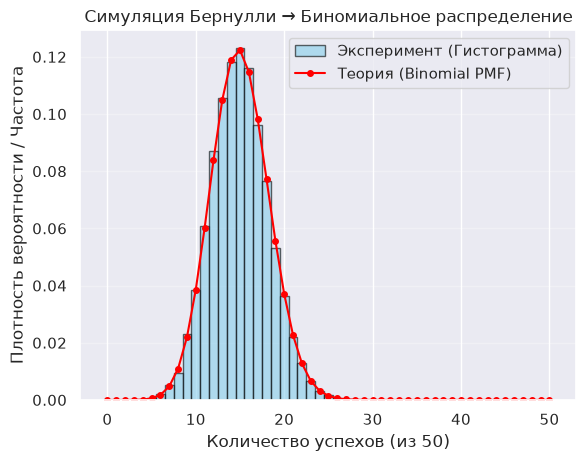

In [11]:
rng = np.random.default_rng(seed=42)

n = 50
p = 0.3
size = 10000
samples = rng.binomial(n=n, p=p, size=size)

# bins выбираем так, чтобы каждый столбик соответствовал целому числу
plt.hist(samples, bins=np.arange(0, n + 2) - 0.5, density=True, 
         alpha=0.6, color='skyblue', edgecolor='black', label='Эксперимент (Гистограмма)')

x = np.arange(0, n + 1)
pmf_theoretical = stats.binom.pmf(x, n=n, p=p)
plt.plot(x, pmf_theoretical, 'ro-', ms=4, label='Теория (Binomial PMF)', color='red')

plt.title('Симуляция Бернулли → Биномиальное распределение')
plt.xlabel('Количество успехов (из 50)')
plt.ylabel('Плотность вероятности / Частота')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

### Связь распределения Бернулли и биномиального распределения

В формулировке задачи указано: *«Сгенерируйте сумму 50 бернулли»*. 
При этом в коде мы пишем `n=50`, хотя для распределения Бернулли параметр всегда $n=1$. Здесь нет ошибки, так как эти подходы математически эквивалентны.

*   **1 испытание:** Бросок одной монетки с вероятностью успеха $p = 0.3$ (испытание Бернулли).
*   **1 эксперимент (серия):** Группа из $n = 50$ независимых испытаний. Результат эксперимента — одно целое число от $0$ до $50$ (сумма успехов).
*   **$100\,000$ экспериментов (`size=100000`):** Количество повторений этой серии для сбора статистики.

#### Математическое определение
По определению из теории вероятностей, **биномиальное распределение** $Bin(n, p)$ — это закон распределения случайной величины $X$, которая равна **сумме $n$ независимых случайных величин Бернулли** $B_i$ с одинаковой вероятностью успеха $p$:

$$ [X = B_1 + B_2 + \dots + B_n] $$

Где каждая величина $(B_i)$ принимает значения:
* $1$ (успех) — с вероятностью $p$
* $0$ (неудача) — с вероятностью $1 - p$

#### Сравнение подходов в коде

Мы можем смоделировать этот процесс в NumPy двумя абсолютно идентичными по смыслу способами:

1. **Прямая симуляция (сложная):** Сгенерировать матрицу из $10000$ серий по $50$ индивидуальных испытаний Бернулли ($n=1$), а затем сложить их вручную по строкам.
2. **Оптимизированная симуляция (простая):** Использовать готовое биномиальное распределение с параметром $n=50$.

```python
# Способ 1: Честное сложение 50 случайных величин Бернулли
matrix_bern = rng.binomial(n=1, p=0.3, size=(10000, 50))
samples_sum = matrix_bern.sum(axis=1)  # Массив сумм размера 10000

# Способ 2: Оптимизированный вызов биномиального распределения
samples_binom = rng.binomial(n=50, p=0.3, size=10000)
```

**Вывод:** Функция `rng.binomial(n=50, ...)` под капотом сразу возвращает результат суммы пятидесяти испытаний Бернулли. Это экономит память компьютера и работает значительно быстрее, избавляя нас от необходимости создавать огромные промежуточные матрицы из нулей и единиц.


---
---
3. **ЦПТ на равномерном.** Усредняйте `n = 1, 2, 5, 10, 30` равномерно распределённых чисел. Покажите, как гистограмма меняется от прямоугольника к колоколу.


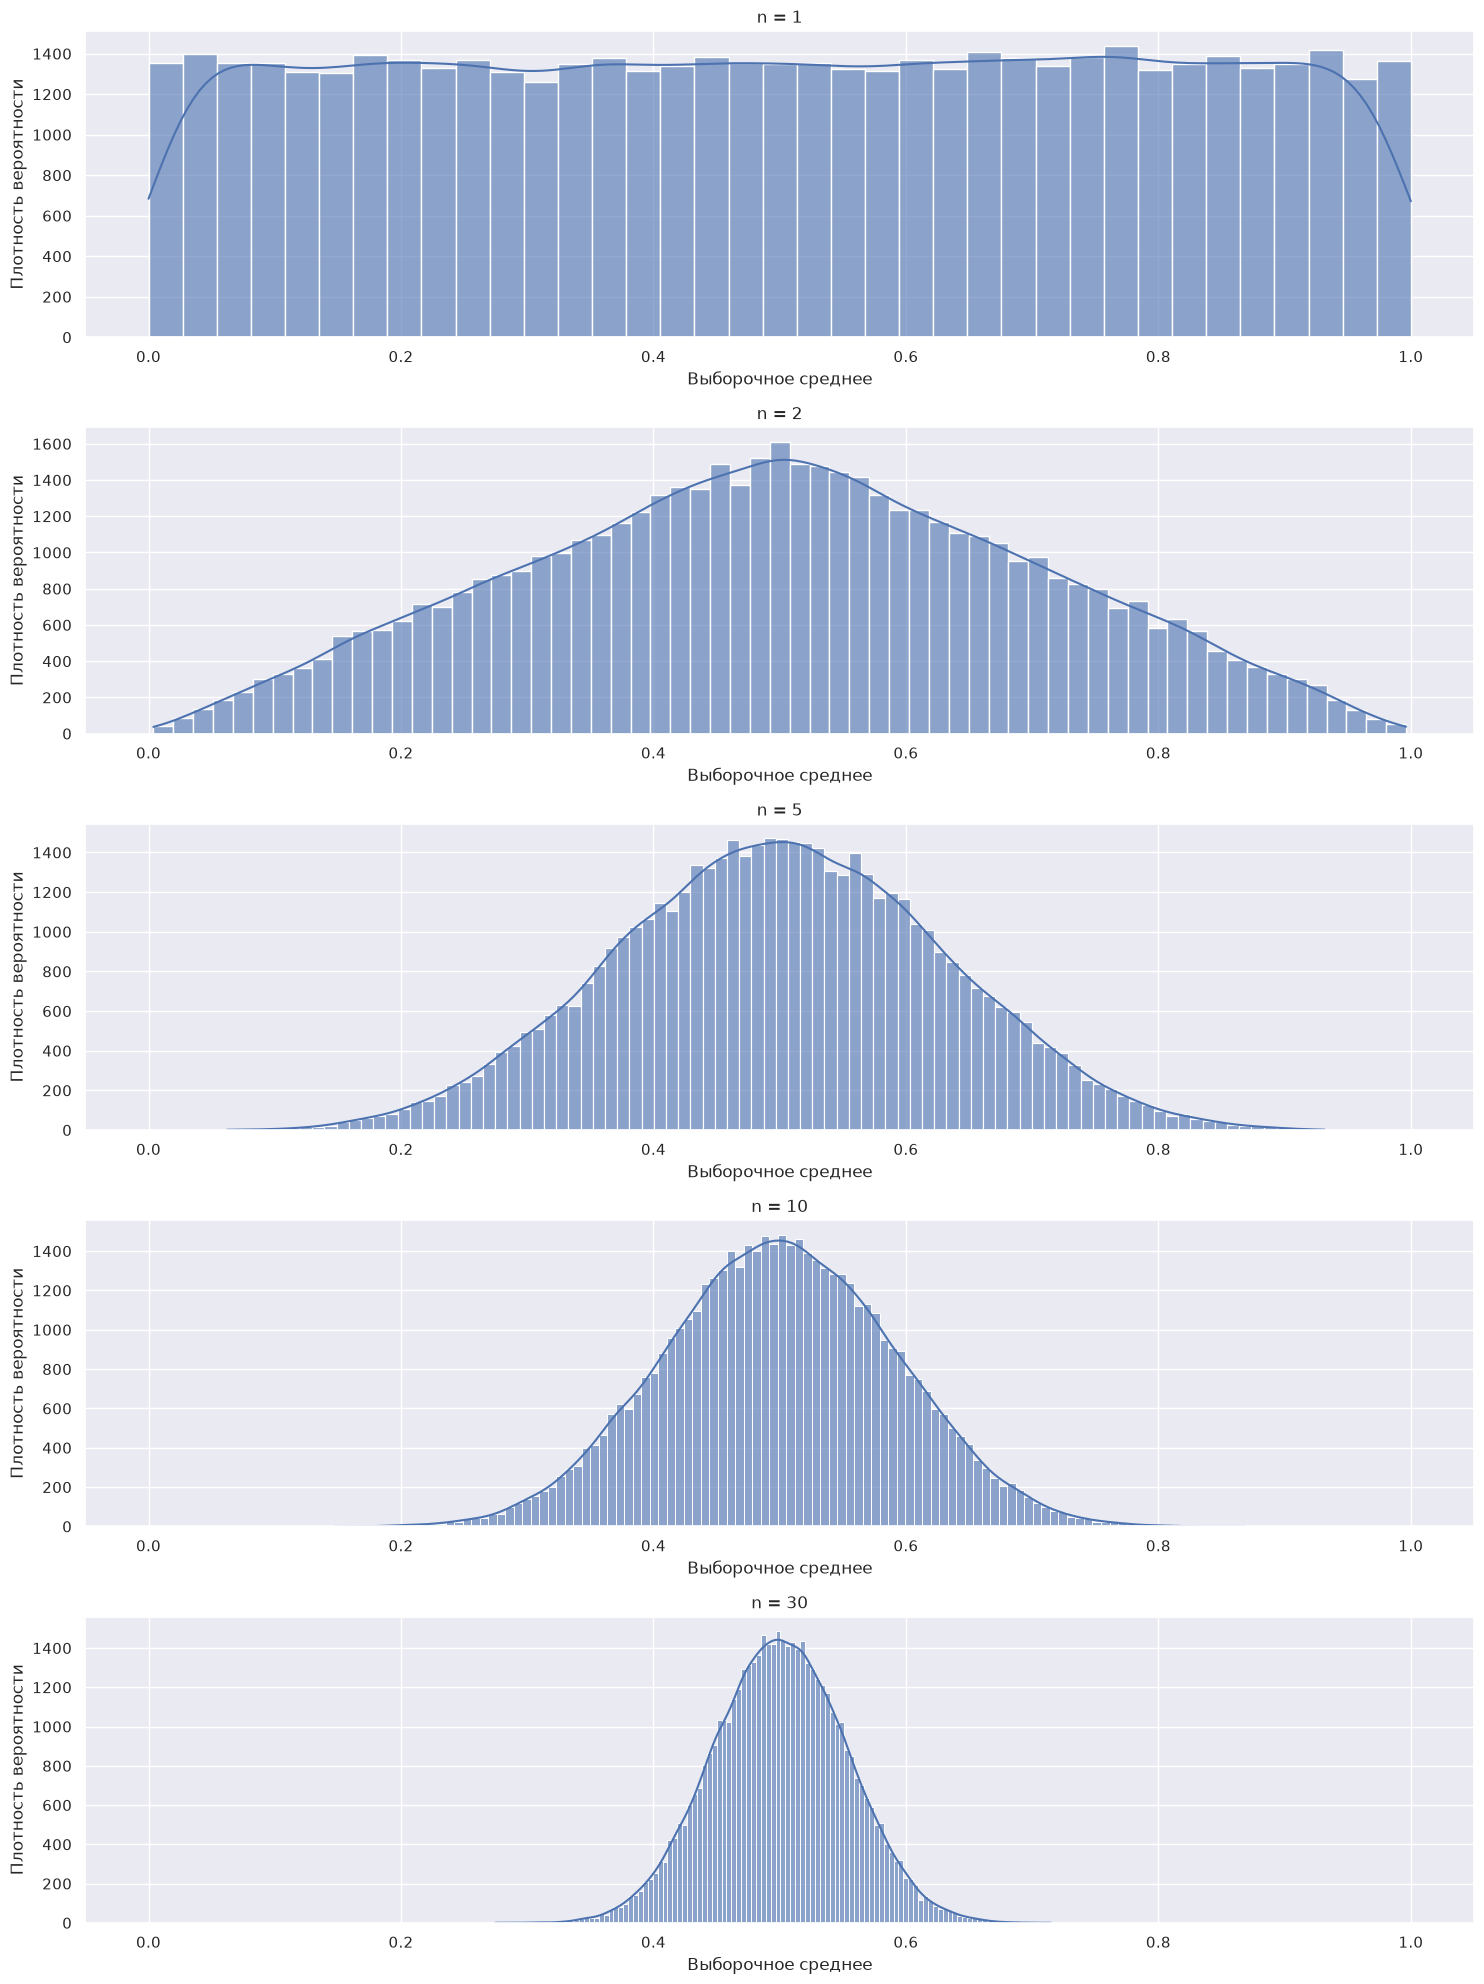

In [12]:
n_val = [1, 2, 5, 10, 30]
n_simulations = 50000

fig, axes = plt.subplots(5, 1, figsize=(15, 20))

for i, n in enumerate(n_val):
    data = np.random.uniform(low=0, high=1, size=(n_simulations, n))
    means_data = np.mean(data, axis=1)

    sns.histplot(data=means_data, kde=True, alpha=0.6, ax=axes[i])
    axes[i].set_title(f"n = {n}")
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].set_xlabel("Выборочное среднее")
    axes[i].set_ylabel("Плотность вероятности")

plt.tight_layout()
plt.show()

---
---
4. **Q-Q plot.** Постройте Q-Q plot для нормально распределённых данных и для экспоненциальных. Объясните разницу.


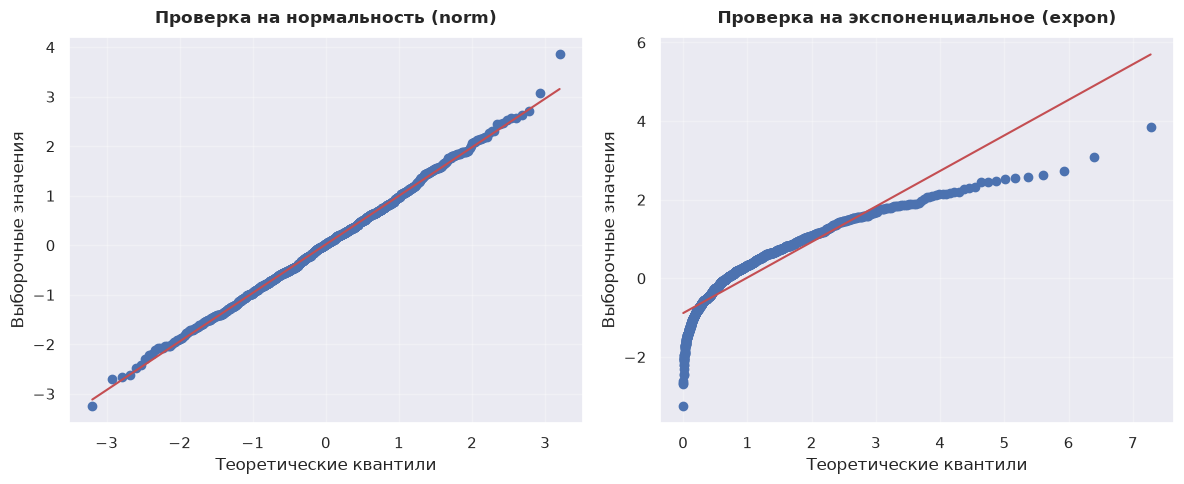

In [13]:
np.random.seed(42)
samples_normal = np.random.normal(loc=0, scale=1, size=1000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

distributions = ["norm", "expon"]
titles = ["Проверка на нормальность (norm)", "Проверка на экспоненциальное (expon)"]

for ax, dist, title in zip(axes, distributions, titles):
    stats.probplot(x=samples_normal, dist=dist, plot=ax)

    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Теоретические квантили")
    ax.set_ylabel("Выборочные значения")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 1. Что расположено на осях

* **Ось Y (Выборочные значения / Sample Quantiles):**
  Это ваши реальные 1000 чисел, отсортированные от самого маленького к самому большому. На левом графике значения идут примерно от -3.5 до +4. Это шкала ваших исходных данных.
* **Ось X (Теоретические квантили / Theoretical Quantiles):**
  Это значения, которые должны были бы получиться, если бы мы взяли идеальное математическое распределение (нормальное или экспоненциальное) и разбили его на такие же 1000 шагов (квантилей). На левом графике (нормальное) шкала X идет от -3 до +3. На правом графике (экспоненциальное) шкала X идет от 0 до 7, так как экспоненциальное распределение не бывает отрицательным и имеет длинный правый хвост.

### 2. Как сопоставлять оси и точки (Как читать график)

Каждая синяя точка на графике имеет координаты **(X, Y)**:
* Берётся конкретный процент выборки (например, самые минимальные числа, или ровно середина данных, или топ-5% наибольших чисел).
* На **оси Y** откладывается значение этого элемента из вашего реального набора.
* На **оси X** откладывается значение, которое стояло бы на этом же самом месте в идеальной математической модели.

#### Пример чтения точек на левом графике:
* **Центр (Медиана):** Найдите `0` на оси X и поднимитесь к синей точке. Проекция на ось Y тоже будет примерно `0`. Это значит, что центральное значение ваших данных совпадает с центром идеального нормального распределения.
* **Правый «хвост» (Максимумы):** Найдите крайнюю правую точку. Её координата по X (теория) — около `3.2`, а по Y (выборка) — около `3.8`. Точка немного ушла вверх от красной линии, что говорит о наличии одного случайного выброса в вашей выборке (число оказалось чуть больше, чем в среднем по теории).

### 3. Главный вывод из сопоставления

* **Левый график (norm):** Синие точки практически на всём протяжении сливаются с красной линией. Это означает, что для любого процента данных (хоть для минимальных, хоть для средних, хоть для максимальных) их реальное значение (Y) в точности равно теоретическому (X). **Вывод: данные распределены нормально.**
* **Правый график (expon):** Синие точки образуют сильный изгиб (дугу) и не лежат на красной линии. Например, в районе 0 по теории (X) наши реальные данные (Y) уходят глубоко в минус (до -3), чего у экспоненциального распределения быть не может. **Вывод: данные категорически не соответствуют экспоненциальному закону.**


---
---
5. **Оценка параметров.** Сгенерируйте 1000 точек из `N(μ=3, σ=2)`. Оцените μ, σ методом моментов и методом максимального правдоподобия.


In [ ]:
np.random.seed(42)
true_mu = 3
true_sigma = 2
samples = np.random.normal(loc=true_mu, scale=true_sigma, size=1000)

## Метод моментов
mu_mm = np.mean(samples)
sigma_mm = np.sqrt(np.var(samples, ddof=0))

# Метод максимального правдоподобия
# stats.norm.fit использует метод максимального правдоподобия под капотом
mu_mle, sigma_mle = stats.norm.fit(samples)

print("Истинные параметры:     mu = {}, sigma = {}".format(true_mu, true_sigma))
print("Метод моментов:         mu = {:.4f}, sigma = {:.4f}".format(mu_mm, sigma_mm))
print("Метод макс. правдопод.: mu = {:.4f}, sigma = {:.4f}".format(mu_mle, sigma_mle))

Истинные параметры:     mu = 3, sigma = 2
Метод моментов:         mu = 3.0387, sigma = 1.9575
Метод макс. правдопод.: mu = 3.0387, sigma = 1.9575


## 5. Оценка параметров распределения $N(\mu=3, \sigma=2)$

Для оценки неизвестных параметров $\mu$ (математическое ожидание) и $\sigma$ (стандартное отклонение) непрерывного нормального распределения используются два классических статистических метода:

---

### 1. Метод моментов (Method of Moments)

**Идея метода:** Теоретические моменты распределения приравниваются к их выборочным (экспериментальным) аналогам. Количество уравнений равно количеству оцениваемых параметров (в нашем случае два: $\mu$ и $\sigma$).

*   **Первый начальный момент:** Теоретическое матожидание $M[X] = \mu$ приравнивается к выборочному среднему $\bar{X}$:
    $$\mu = \bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i$$

*   **Второй центральный момент:** Теоретическая дисперсия $D[X] = \sigma^2$ приравнивается к выборочной дисперсии $S^2$:
    $$\sigma^2 = S^2 = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})^2$$

**Формулы оценок метода моментов (ММ):**
*   $\hat{\mu}_{MM} = \bar{X}$
*   $\hat{\sigma}_{MM} = \sqrt{S^2}$ (смещённая оценка стандартного отклонения)

---

### 2. Метод максимального правдоподобия (Maximum Likelihood Estimation — MLE)

**Идея метода:** За основу берется функция правдоподобия $L(\mu, \sigma^2)$, которая описывает плотность совместной вероятности всей выборки. Задача — найти такие значения параметров, при которых вероятность получить именно текущую выборку будет максимальной.

Для нормального распределения функция правдоподобия имеет вид произведения плотностей вероятностей всех точек выборки:
$$L(\mu, \sigma^2) = \prod_{i=1}^{n} \frac{1}{\sigma \sqrt{2\pi}} \exp\left( -\frac{(X_i - \mu)^2}{2\sigma^2} \right)$$

Чтобы найти максимум, функцию логарифмируют и берут частные производные по $\mu$ и $\sigma$, приравнивая их к нулю:
$$\ln L(\mu, \sigma^2) = -\frac{n}{2}\ln(2\pi) - n\ln(\sigma) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (X_i - \mu)^2$$

**Формулы оценок метода максимального правдоподобия (ММП):**
Для нормального распределения аналитическое решение уравнений правдоподобия совпадает с формулами метода моментов:
*   $\hat{\mu}_{MLE} = \frac{1}{n} \sum_{i=1}^{n} X_i$
*   $\hat{\sigma}_{MLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})^2}$

*Примечание:* Хотя для нормального закона формулы совпали, ММП обладает свойством **асимптотической эффективности** (при росте размера выборки $n \to \infty$ он даёт минимально возможную дисперсию ошибки оценки).


---
---
6. **2D нормальное.** Сгенерируйте `N(0, Σ)` с `Σ = [[1, 0.9], [0.9, 1]]`. Постройте Scatter plot (диаграмма рассеяния) и контуры плотности (Density Contour).


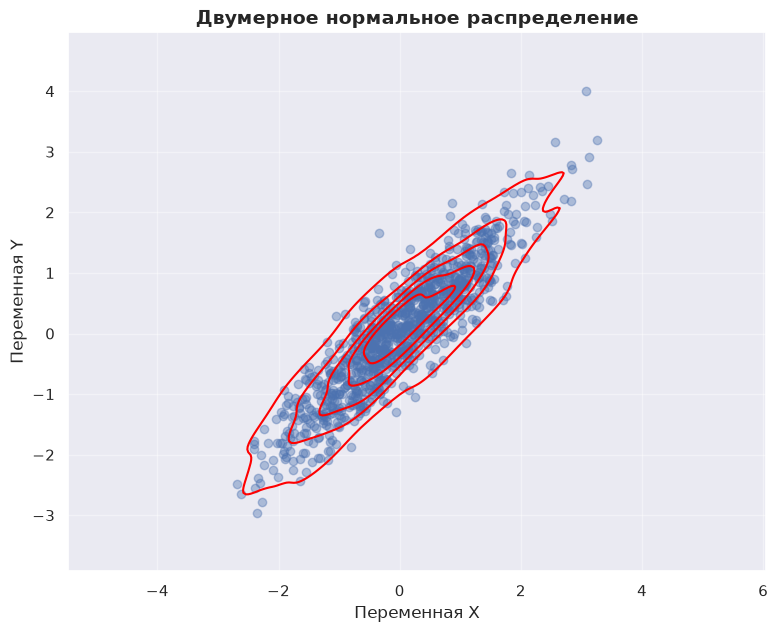

In [23]:
mean_2d = np.array([0.0, 0.0])
cov_2d = np.array([[1.0, 0.9],
                   [0.9, 1.0]])

samples_multivariate = np.random.multivariate_normal(mean=mean_2d, cov=cov_2d, size=1000)
X, Y = samples_multivariate[:, 0], samples_multivariate[:, 1]

plt.figure(figsize=(9, 7))
plt.scatter(x=X, y=Y, alpha=0.4)
sns.kdeplot(x=X, y=Y, levels=6, color="red")

plt.title('Двумерное нормальное распределение', fontsize=14, fontweight='bold')
plt.xlabel('Переменная X', fontsize=12)
plt.ylabel('Переменная Y', fontsize=12)

# Устанавливаем равный масштаб осей, чтобы эллипс не искажался геометрически
plt.axis('equal') 
plt.grid(True, alpha=0.4)
plt.show()


---
---
7. **Тяжёлые хвосты.** Сравните, насколько часто бывают «события 5σ» у нормального и у Коши. Сделайте 1 000 000 семплов каждого.


# Сравнение распределений: Гаусс vs Коши

Несмотря на внешнее сходство (оба графика плотности напоминают симметричный колокол), распределение Гаусса (нормальное) и распределение Коши имеют принципиально разную математическую природу.

---

### 1. Распределение Гаусса (Нормальное распределение)
Это фундаментальное распределение, которое возникает, когда на величину действует множество мелких, независимых случайных факторов (*Центральная предельная теорема*).

*   **Плотность вероятности:** 
    $$f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$
*   **Хвосты распределения:** «Тонкие». Вероятность встретить значение, далекое от центра, падает экспоненциально быстро.
*   **Правило трёх сигм:** 
    *   $68.2\%$ данных лежат в пределах $\pm1\sigma$
    *   $95.4\%$ данных лежат в пределах $\pm2\sigma$
    *   $99.7\%$ данных лежат в пределах $\pm3\sigma$
*   **Свойства:** Имеет строго определенные конечные параметры — математическое ожидание (центр $\mu$) и дисперсию (разброс $\sigma^2$).
*   **Примеры:** Рост людей, случайный шум в радиосигнале, погрешности измерений.

---

### 2. Распределение Коши
«Бунтарь» в мире статистики. Математически его можно получить как отношение двух независимых стандартных нормальных величин.

*   **Плотность вероятности:** 
    $$f(x) = \frac{1}{\pi \gamma \left[1 + \left(\frac{x - x_0}{\gamma}\right)^2\right]}$$
*   **Хвосты распределения:** «Тяжёлые» или «толстые» (heavy-tailed). Вероятность получить гигантский выброс здесь в сотни раз выше, чем у Гаусса.
*   **Главный парадокс:** У распределения Коши **не существуют математическое ожидание и дисперсия**. Интегралы для их поиска расходятся. Если считать среднее арифметическое выборки Коши, оно будет хаотично прыгать при добавлении новых точек и никогда не сойдется к одному числу.
*   **Примеры:** Распределение светового луча от вращающегося маяка на бесконечную прямую стену; форма спектральных линий в квантовой физике (распределение Брейта — Вигнера).

---

### Главное отличие одной фразой:
> **У Гаусса экстремальные выбросы практически невозможны, а у Коши гигантские выбросы — это норма жизни.**


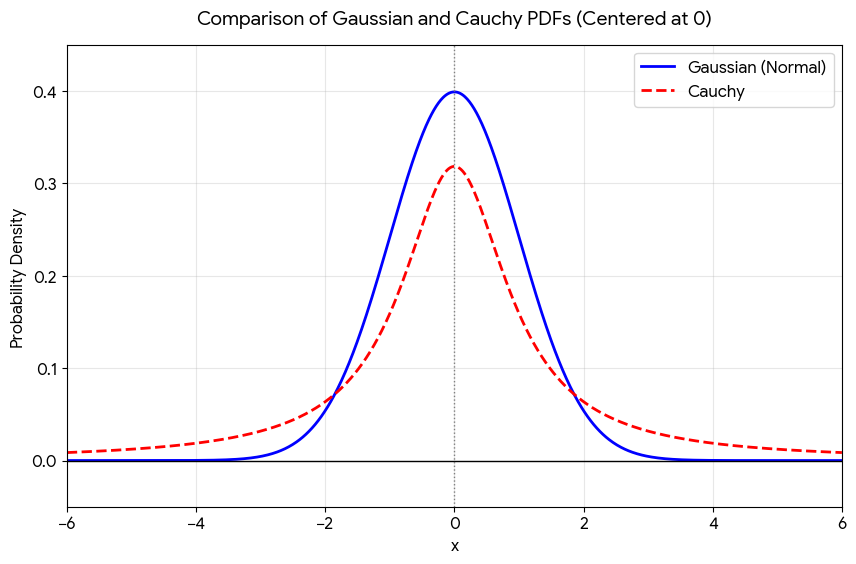

In [32]:
n = 1000000
gauss_samples = np.random.normal(loc=0, scale=1, size=n)
cauchy_samples = np.random.standard_cauchy(size=n)

gauss_anomalies = np.sum(np.abs(gauss_samples) > 5)
cauchy_anomalies = np.sum(np.abs(cauchy_samples) > 5)

print(f"Событий > 5σ у Гаусса: {gauss_anomalies} шт.")
print(f"Событий > 5σ у Коши:  {cauchy_anomalies:,} шт.)")


Событий > 5σ у Гаусса: 2 шт.
Событий > 5σ у Коши:  125,974 шт.)


---
---
8. **Бета как prior.** Подбросили 5 монет, 4 орла. Используйте Beta(2, 2) как prior. Постройте posterior.


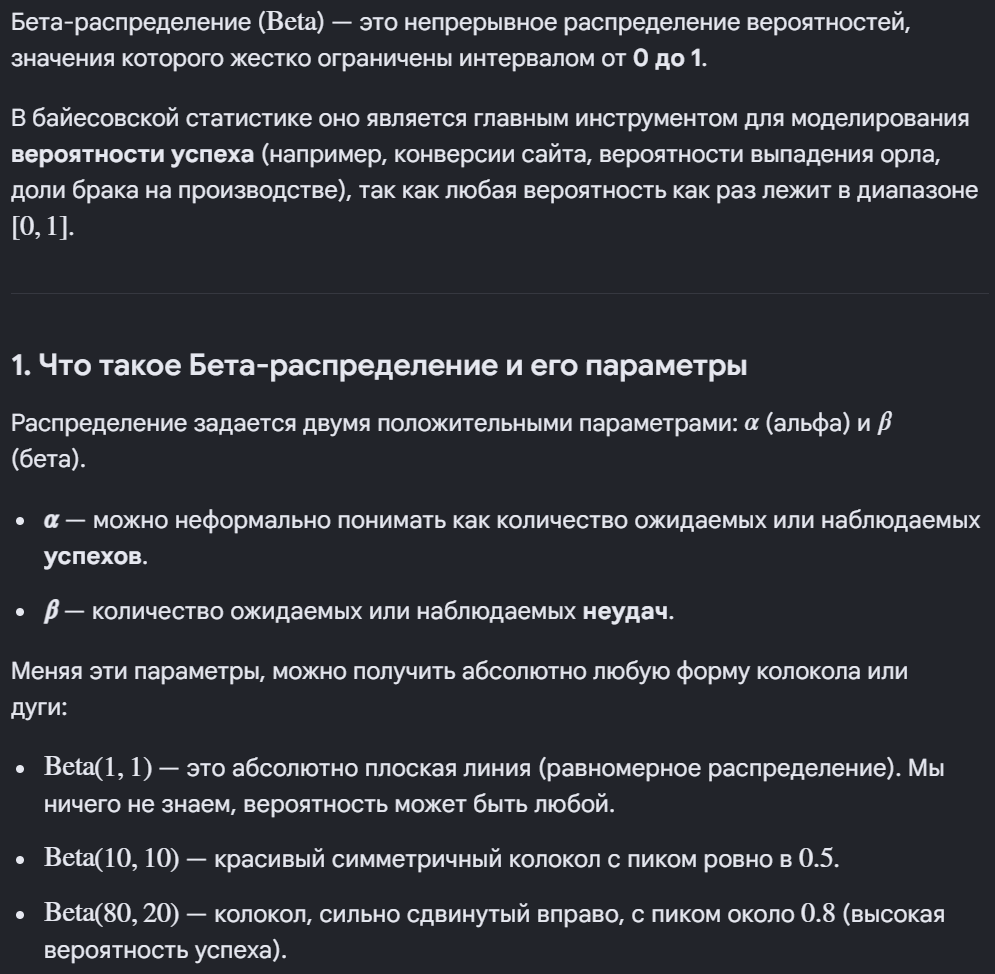
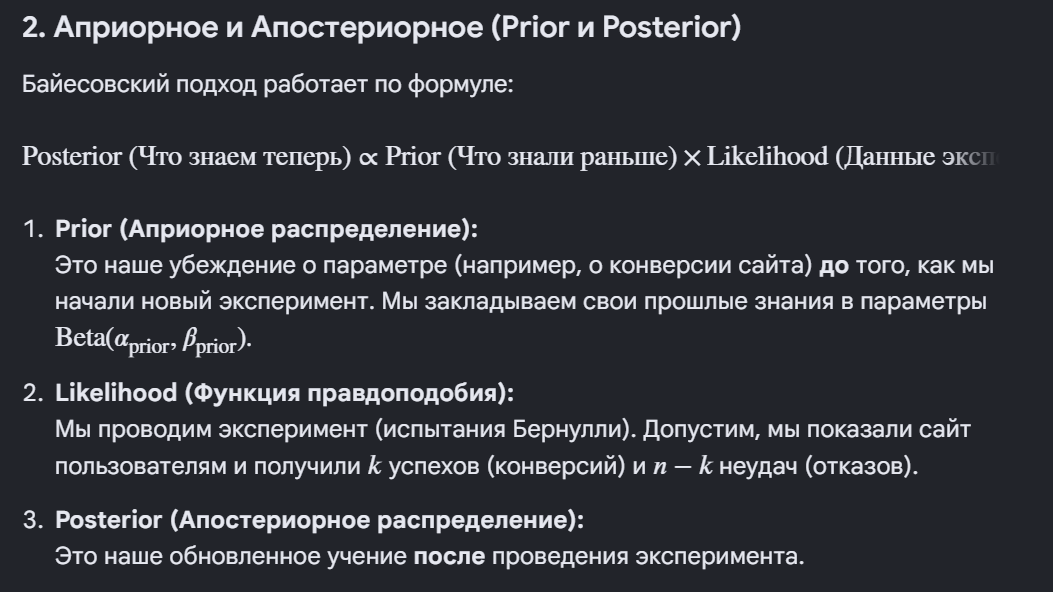
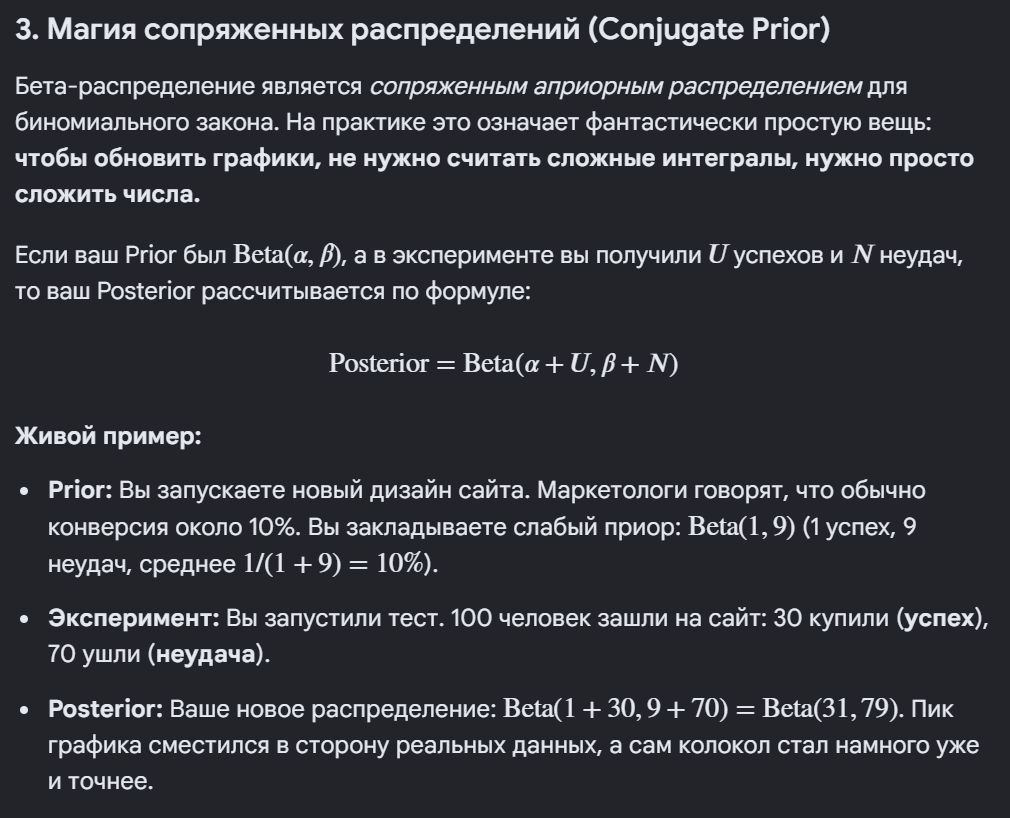

Теоретические параметры Posterior: Beta(a=6, b=3)
Выборочное среднее (Наиболее вероятный шанс орла): 0.6673
Выборочная дисперсия (Мера неопределенности):      0.0223



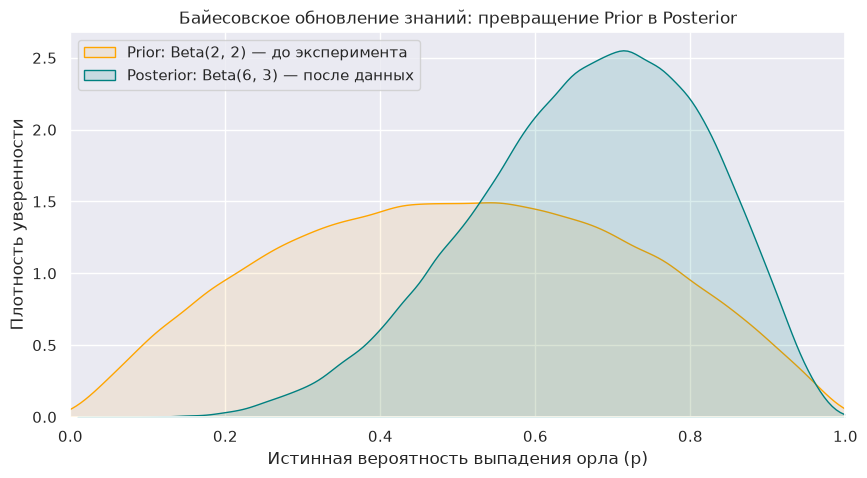

In [52]:

np.random.seed(42)
sns.set_theme(style="darkgrid")

n_coin = 5
n_eagle = 4
n_tails = n_coin - n_eagle # Количество решек (неудач)

# Параметры априорного распределения (Prior)
alpha_prior = 2
beta_prior = 2

# Математическое байесовское обновление параметров
alpha_posterior = alpha_prior + n_eagle
beta_posterior = beta_prior + n_tails

# Генерируем выборки для визуализации ДО и ПОСЛЕ
samples_prior = np.random.beta(a=alpha_prior, b=beta_prior, size=100000)
samples_beta_posterior = np.random.beta(a=alpha_posterior, b=beta_posterior, size=100000)

print(f"Теоретические параметры Posterior: Beta(a={alpha_posterior}, b={beta_posterior})")
print(f"Выборочное среднее (Наиболее вероятный шанс орла): {samples_beta_posterior.mean():.4f}")
print(f"Выборочная дисперсия (Мера неопределенности):      {samples_beta_posterior.var():.4f}\n")

plt.figure(figsize=(10, 5))

sns.kdeplot(data=samples_prior, label="Prior: Beta(2, 2) — до эксперимента", color="orange", fill=True, alpha=0.1)
sns.kdeplot(data=samples_beta_posterior, label=f"Posterior: Beta({alpha_posterior}, {beta_posterior}) — после данных", color="teal", fill=True, alpha=0.15)

plt.title("Байесовское обновление знаний: превращение Prior в Posterior")
plt.xlabel("Истинная вероятность выпадения орла (p)")
plt.ylabel("Плотность уверенности")
plt.xlim(0, 1) # Бета-распределение строго зажато между 0 и 1
plt.legend()
plt.show()


---

## Анализ результатов эксперимента

Посмотрите на получившийся график:
1. **Линия Prior (оранжевая)** была широкой и плавной, с центром на $0.5$. Мы думали, что монета честная, но допускали любые варианты.
2. **Линия Posterior (бирюзовая)** под действием данных (4 орла из 5) заметно сузилась и сместилась вправо. Ее пик и математическое среднее теперь находятся в точке $\frac{6}{6+3} \approx 0.6667$.

### Почему среднее равно 0.66, а не 0.80?
Чистая пропорция эксперимента дает нам $\frac{4}{5} = 0.80$. Метод максимального правдоподобия (MLE), который верит только чистым данным, выдал бы нам ответ $0.80$. 

Но наше Байесовское MAP-оценивание учитывает априорные знания о том, что монеты обычно честные ($0.5$). Поскольку данных мало (всего 5 бросков), Prior частично «сопротивляется» и утягивает оценку от экстремальных $0.80$ ближе к центру — до $0.66$. Если мы продолжим бросать эту монету и получим, например, 400 орлов из 500, влияние априорного мнения сойдет на нет, и пик графика практически идеально встанет на отметку $0.80$.


---
---
# Что на самом деле показывает Бета-распределение?

Если большинство классических распределений (Нормальное, Биномиальное, Пуассон) моделируют поведение **физических величин** (рост людей, количество кликов, число заходов на сервер), то Бета-распределение моделирует **нашу уверенность в значении скрытых параметров**. 

Говоря простыми словами, Бета-распределение — это **«вероятность для вероятности»**.

---

## Главное отличие от Биномиального распределения

Чтобы понять суть, сравним прямую и обратную (Байесовскую) задачи статистики:

* **Прямая задача (Биномиальный закон):** 
  > *«Мы точно знаем, что монетка честная ($p=0.5$). Мы бросаем её 10 раз. Какова вероятность, что выпадет ровно 7 орлов?»* 
  Здесь параметр $p$ нам **известен**, и мы ищем вероятность получить конкретное количество физических объектов (орлов).

* **Обратная задача (Бета-распределение):** 
  > *«Перед нами незнакомая монета. Мы бросили её 10 раз и получили 7 орлов. Мы не знаем истинный шанс $p$ выпадения орла для этой монеты. Какова вероятность, что скрытый шанс $p$ равен $0.5$? А $0.7$? А $0.9$?»*
  Здесь данные эксперимента нам **известны**, а сам шанс $p$ — это случайная непрерывная величина. Бета-распределение показывает, какие значения этой вероятности наиболее правдоподобны.

---

## Как читать элементы графика Бета-распределения?

Если построить график плотности (PDF) Бета-распределения для продуктовой метрики (например, конверсии или CTR), его элементы расшифровываются следующим образом:

1. **Ось X (всегда строго от 0 до 1):** Показывает все теоретически возможные значения скрытого параметра (от 0% до 100% конверсии).
2. **Пик графика (вершина колокола):** Указывает на самое правдоподобное, наиболее ожидаемое значение конверсии на основе той истории, которую мы уже успели накопить.
3. **Ширина графика (разброс):** Наглядно демонстрирует **уровень нашего незнания и неопределенности**:
   * *Широкий и плоский график* означает: данных слишком мало, и истинная конверсия может оказаться практически любой. Риск ошибки велик.
   * *Узкий и острый «нож»* означает: данных накоплено колоссальное количество, и мы снайперски точно знаем истинный шанс успеха.

---

## Примеры вопросов из реального бизнеса, на которые отвечает Бета-распределение

* **Проблема малых данных:** *«Новый менеджер сделал всего 3 звонка и закрыл 2 сделки. Его конверсия на бумаге — 66.7%. Стоит ли выписывать ему премию как лучшему сотруднику?»*
  Бета-распределение построит очень широкую кривую и ответит аналитику: *«Рано. При такой короткой истории истинная конверсия этого сотрудника с высокой вероятностью может оказаться и 20%, и 85%. Нужно накопить еще хотя бы 30 звонков»*.

* **Сравнение сущностей (A/B-тесты):** *«Вариант А нажал 1 пользователь из 2. Вариант Б нажали 50 пользователей из 100. У обоих конверсия 50%. Какой вариант внедрять на проде?»*
  Наложив два Бета-распределения друг на друга, аналитик увидит, что график варианта А размазан по всей оси, а график варианта Б — узкий и стабильный. Бета-распределение позволяет строго рассчитать математический риск падения метрик при раскатке.

* **Холодный старт в рекомендациях:** *«ИИ-модель должна рекомендовать пользователям товары. На склад привезли абсолютно новый худи, его еще никто не видел. Какую вероятность клика (CTR) заложить для него алгоритму, чтобы честно сравнить его с джинсами, у которых CTR стабильно равен 10%?»*
  В этот момент Бета-распределение принимает параметры $Beta(1,1)$ — абсолютно плоскую прямую линию, сообщая модели: *«Мы ничего не знаем про этот товар. Дай ему шанс, покажи его случайному числу пользователей, чтобы мы собрали первые успехи/неудачи и сузили график»*.


---
---
# Что показывают цифры на оси Oy (Плотность вероятности)?

Когда мы строим непрерывные распределения (например, Нормальное или Бета), значения на вертикальной оси $Oy$ — это **плотность вероятности $f(x)$**, а не точная вероятность $P(X)$.

---

## Главное правило: Вероятность точки равна нулю

В непрерывном мире (где значения на оси $Ox$ дробные и бесконечные) вероятность того, что конверсия будет равна *строго* $0.60000000...$ до бесконечного знака после запятой, **равна нулю**. 

Поэтому мы не можем измерить вероятность в одной конкретной точке. Вероятность в непрерывном распределении — это всегда **площадь под кривой графика** на определенном интервале (например, от $0.55$ до $0.65$).

---

## Почему на оси Oy бывают числа больше 1?

Вспоминаем **Условие нормировки**: 
> *«Вся площадь под графиком плотности вероятности всегда строго равна единице ($1.0$ или 100%).»*

Площадь прямоугольника (или колокола) — это его ширина, умноженная на высоту. 
* Так как Бета-распределение живет на оси $Ox$ на очень узком отрезке (всего от $0$ до $1$), его **ширина изначально очень маленькая**.
* Если мы накопили много данных (например, 300 успехов и 200 неудач), график сжимается в очень узкую полоску по ширине (например, распределение зажато в интервале от $0.58$ до $0.62$).
* Чтобы общая площадь этого сверхузкого «ножа» осталась равной единице, график вынужден **компенсировать ширину высотой и устремляться высоко вверх**.

### Пример «на пальцах»
Представьте идеальный прямоугольник на графике, площадь которого должна быть равна $1$:
* Если его ширина на оси $Ox$ равна $1$ (от $0$ до $1$), то его высота на оси $Oy$ будет равна **$1$** ($1 \times 1 = 1$).
* Если его ширина уменьшилась до $0.1$ (например, от $0.5$ до $0.6$), то его высота на оси $Oy$ обязана стать равной **$10$**, чтобы площадь осталась прежней ($0.1 \times 10 = 1$).
* Если ширина сжалась до $0.01$, высота на оси $Oy$ взлетит до **$100$** ($0.01 \times 100 = 1$).

---

## Как аналитику интерпретировать значения на Oy?

1. **Для точных расчетов**: Числа на оси $Oy$ сами по себе вам не нужны. Чтобы узнать реальную вероятность (например, *«каков шанс, что конверсия кнопки лежит между 55% и 65%?»*), нужно взять интеграл — то есть посчитать площадь заштрихованной области между этими точками. В Python это делается одной командой:
   ```python
   # Вероятность, что конверсия лежит между 0.55 и 0.65 для Beta(300, 200)
   prob = stats.beta.cdf(0.65, 300, 200) - stats.beta.cdf(0.55, 300, 200)
   ```
2. **Для визуального анализа**: Используйте ось $Oy$ как **шкалу относительного сравнения**. Если при $X=0.6$ высота графика равна $40$, а при $X=0.5$ она равна $10$, это значит, что значение конверсии $60\%$ ровно **в 4 раза более вероятно (правдоподобно)**, чем значение $50\%$.


---
---
---

# Шпаргалка для собеседования: Вероятностный чек-лист Data Science

Этот раздел содержит детальный разбор пяти ключевых концепций теории вероятностей и математической статистики, знание которых регулярно проверяют на секциях по Machine Learning и продуктовой аналитике.

---

## 1. Числовые характеристики базовых распределений

Знание математического ожидания $\mathbb{E}[X]$ (центр) и дисперсии $\text{Var}(X)$ (разброс) позволяет мгновенно оценить характер случайной величины без построения графиков.

| Распределение | Параметры | Матожидание $\mathbb{E}[X]$ | Дисперсия $\text{Var}(X)$ | Продуктовый / бизнес-смысл |
| :--- | :--- | :--- | :--- | :--- |
| **Бернулли** | $p$ (шанс успеха) | $p$ | $p(1 - p)$ | Исход одного бинарного действия (кликнул/не кликнул). |
| **Биномиальное** | $n$ (попытки), $p$ | $n \cdot p$ | $n \cdot p \cdot (1 - p)$ | Количество успехов за серию из $n$ шагов (всего покупок). |
| **Пуассон** | $\lambda$ (интенсивность) | $\lambda$ | $\lambda$ | Число редких событий за фиксированное время (запросы к API). |
| **Нормальное** | $\mu$ (центр), $\sigma$ (разброс) | $\mu$ | $\sigma^2$ | Ошибки измерения, природные метрики, веса моделей. |
| **Экспоненциальное** | $\lambda$ (интенсивность) | $\frac{1}{\lambda}$ | $\frac{1}{\lambda^2}$ | Время или расстояние между двумя событиями (время удержания). |

> **Интересный факт для собеседования**: Распределение Пуассона уникально тем, что его математическое ожидание строго равно его дисперсии ($\mathbb{E}[X] = \text{Var}(X) = \lambda$). Если на реальных данных вы видите, что среднее число заходов на сайт равно 5, а дисперсия равна 25 — это сигнал, что данные не пуассоновские (такой эффект называется *сверхдисперсией* или *overdispersion*).


---

## 2. Что такое Центральная Предельная Теорема (ЦПТ)

**Центральная предельная теорема (ЦПТ)** утверждает: если взять выборку из большого количества ($n \ge 30$) независимых случайных величин, извлеченных из **любого** распределения (даже дикого, плоского или сильно скошенного), их **выборочное среднее** (или сумма) будет распределено примерно **нормально**.

* **Зачем это в аналитике и ML?** На ЦПТ держится вся математика контролируемых A/B-тестов. Время сессии или доходы пользователей на сайтах практически никогда не распределены нормально (там обычно длинные скошенные хвосты). Но благодаря ЦПТ, **средний чек** или **среднее время** по группе пользователей гарантированно будут иметь форму колокола Гаусса. Это дает нам полное право легально применять параметрические критерии (например, $T$-тест Стьюдента) и рассчитывать корректный $p$-value.


---

## 3. Геометрия правила 68–95–99.7

Это математическое свойство исключительно **нормального распределения**, которое показывает, какая доля данных гарантированно попадает в рамки определенного количества стандартных отклонений ($\sigma$) от центра ($\mu$):

* **$1\sigma$ (Интервал $[\mu \pm \sigma]$)**: содержит примерно **68.27%** всех объектов выборки.
* **$2\sigma$ (Интервал $[\mu \pm 2\sigma]$)**: содержит примерно **95.45%** всех объектов выборки.
* **$3\sigma$ (Интервал $[\mu \pm 3\sigma]$)**: содержит примерно **99.73%** всех объектов выборки.
* **Событие $5\sigma$**: экстремальный выброс, шанс встретить который в нормальном мире равен всего $\approx 0.00006\%$ (примерно 1.5 раза на миллион экспериментов).

* **Зачем это в ML?** Это самый популярный метод для базовой фильтрации аномалий (Outliers Detection) на этапе разведочного анализа данных (EDA). Если признак распределен нормально, всё, что вылетает за пределы трех (или пяти) сигм, обычно принудительно удаляется или сглаживается, чтобы экстремальные выбросы не смещали веса модели при обучении.


# Глубокий разбор Вопроса 4: Математический вывод Бинарной Кросс-Энтропии (BCE) из распределения Бернулли

На собеседованиях часто просят объяснить, почему в задачах бинарной классификации (например, логистическая регрессия или предсказание ухода клиентов) используется именно логарифмическая функция потерь, а не привычная среднеквадратичная ошибка (MSE).

Ответ кроется в **Методе максимального правдоподобия (Maximum Likelihood Estimation, MLE)**. Наша цель — найти такие параметры модели (веса), при которых наблюдаемые в реальности метки классов ($0$ и $1$) становятся наиболее вероятными.

---

### Шаг 1. Вероятность одного объекта (Закон Бернулли)
Пусть для конкретного объекта $i$ наша модель выдала число $p_i \in [0; 1]$ — предсказанную вероятность того, что объект принадлежит к классу $1$. 
Истинная метка объекта равна $y_i$ (она может быть строго либо $0$, либо $1$).

Мы можем записать вероятность (правдоподобие) того, что модель угадала ответ для этого одного объекта, через формулу Бернулли:
$$P(y_i \mid p_i) = p_i^{y_i} \cdot (1 - p_i)^{1 - y_i}$$

**Проверим формулу:**
* Если реальный класс объекта $y_i = 1$, то подставив его, мы получим: $p_i^1 \cdot (1 - p_i)^0 = p_i$. Вероятность равна $p_i$.
* Если реальный класс объекта $y_i = 0$, то подставив его, мы получим: $p_i^0 \cdot (1 - p_i)^1 = 1 - p_i$. Вероятность равна $1 - p_i$.
*Формула работает идеально и упаковывает оба условия в одну строчку.*

---

### Шаг 2. Правдоподобие всей выборки (Likelihood)
Если мы предполагаем, что все объекты в нашей обучающей выборке независимы друг от друга, то общая вероятность (правдоподобие $L$) того, что модель одновременно угадает ответы для всей выборки из $n$ объектов, равна **произведению** их индивидуальных вероятностей:
$$L = \prod_{i=1}^{n} P(y_i \mid p_i) = \prod_{i=1}^{n} p_i^{y_i} \cdot (1 - p_i)^{1 - y_i}$$

Наша задача — максимизировать эту функцию $L \to \max$. Однако оптимизировать произведение сотен тысяч вероятностей (чисел типа $0.1 \times 0.2 \times \dots$) на компьютере невозможно: числа быстро превратятся в абсолютный ноль (проблема *underflow*), а вычисление производной от произведения огромно по сложности.

---

### Шаг 3. Переход к логарифму (Log-Likelihood)
Логарифм — это монотонно возрастающая функция. Это значит, что точка максимума функции $L$ и точка максимума функции $\log(L)$ абсолютно совпадают. Применим натуральный логарифм к нашему произведению. По свойствам логарифма ($\log(a \cdot b) = \log a + \log b$ и $\log(a^b) = b \cdot \log a$), наше произведение превращается в **сумму**:
$$\log L = \log \left( \prod_{i=1}^{n} p_i^{y_i} \cdot (1 - p_i)^{1 - y_i} \right) = \sum_{i=1}^{n} \left[ \log(p_i^{y_i}) + \log((1 - p_i)^{1 - y_i}) \right]$$

Выносим степени $y_i$ вперед:
$$\log L = \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]$$

---

### Шаг 4. Финальный шаг к BCE
Мы получили функцию Логарифмического правдоподобия. Её нужно максимизировать. 
Однако в машинном обучении принято **минимизировать** ошибку (интуитивно понятнее, когда идеальная модель имеет ошибку 0, а плохая — большую ошибку). 

Поэтому мы меняем знак всей функции на противоположный (умножаем на $-1$) и делим на количество объектов $n$, чтобы значение функции потерь не зависело от размера датасета. Получаем итоговую формулу **Binary Cross-Entropy**:
$$\text{BCE} = - \frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right] \to \min$$


---
---
# Глубокий разбор Вопроса 5: Математика сопряженности Beta-Prior к Биномиальному Likelihood

На собеседовании вас могут спросить: *«Почему в байесовском выводе все так любят использовать связку Бета-распределения и Биномиального? Что в ней особенного?»*

Ответ: **Аналическая разрешимость без интегралов**. В классической теореме Байеса в знаменателе стоит интеграл полной вероятности данных, который для большинства распределений невозможно взять аналитически (приходится использовать тяжелые приближенные методы вроде MCMC-семплирования). Но для сопряженных распределений знаменатель схлопывается сам.

---

### Шаг 1. Вспоминаем теорему Байеса для непрерывного параметра
Мы хотим найти распределение неизвестной вероятности $p$ (например, конверсии) после получения данных $D$:
$$f(p \mid D) = \frac{P(D \mid p) \cdot f(p)}{P(D)} = \frac{P(D \mid p) \cdot f(p)}{\int_{0}^{1} P(D \mid p) \cdot f(p) \, dp}$$

Поскольку знаменатель $\int_{0}^{1} P(D \mid p) \cdot f(p) \, dp$ — это просто нормировочная константа (число, которое нужно лишь для того, чтобы площадь под итоговым графиком была равна 1), мы можем временно отбросить его и записать пропорцию:
$$f(p \mid D) \propto P(D \mid p) \cdot f(p)$$
*Апостериорная плотность (Posterior) пропорциональна Правдоподобию (Likelihood) $\times$ Априорной плотности (Prior).*

---

### Шаг 2. Подставляем формулы Бета и Биномиального распределений

1. **Априорные знания (Beta Prior):**  
   Плотность Бета-распределения с параметрами $\alpha$ и $\beta$ имеет вид (отбрасывая константы перед переменными):
   $$f(p) \propto p^{\alpha - 1} \cdot (1 - p)^{\beta - 1}$$

2. **Данные эксперимента (Binomial Likelihood):**  
   Мы провели $n$ испытаний и получили $k$ успехов. Вероятность получить такие данные при гипотетическом шансе $p$ равна:
   $$P(D \mid p) = C_n^k \cdot p^k \cdot (1 - p)^{n - k} \propto p^k \cdot (1 - p)^{n - k}$$

---

### Шаг 3. Перемножаем их по теореме Байеса
Теперь найдем форму нашего Posterior распределения, просто перемножив эти две функции:
$$f(p \mid D) \propto \left( p^k \cdot (1 - p)^{n - k} \right) \cdot \left( p^{\alpha - 1} \cdot (1 - p)^{\beta - 1} \right)$$

При умножении степеней с одинаковыми основаниями их показатели складываются. Сгруппируем переменные $p$ и $(1-p)$:
$$f(p \mid D) \propto p^{\alpha + k - 1} \cdot (1 - p)^{\beta + (n - k) - 1}$$

---

### Шаг 4. Узнаем Бета-распределение в лицо
Посмотрите внимательно на получившуюся финальную формулу:
$$p^{\color{teal}{\alpha + k} - 1} \cdot (1 - p)^{\color{crimson}{\beta + n - k} - 1}$$

Она структурно один в один повторяет формулу исходного Бета-распределения, где на месте первого параметра теперь стоит выражение $(\alpha + k)$, а на месте второго — $(\beta + n - k)$. 

Математический круг замкнулся. Нам не пришлось брать интеграл в знаменателе. Мы точно знаем, что константа, которую мы отбросили в начале, вернется ровно в том виде, который необходим для Бета-распределения. 

**Вывод:**
$$\text{Posterior} = Beta(\alpha_{new} = \alpha_{prior} + k, \quad \beta_{new} = \beta_{prior} + n - k)$$
*Где $k$ — количество успехов, а $(n - k)$ — количество неудач в эксперименте.*
